<h2> Nauczanie maszynowe/Ćwiczenia2

Natalia Radzikowska

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error
import scipy.stats as stats
from imblearn.over_sampling import SMOTE
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis

import warnings
warnings.filterwarnings('ignore')

<h4> Zadanie1 (1pkt): Rozważamy dane dotyczące ekspresji genów z odpowiedzi ludzkich astrocytów U251 na zakażenie wirusem grypy H5N1. Badanie to dostarcza informacji na temat odpowiedzi immunologicznej astrocytów na infekcję wirusową.

<h4>
    
- Narysuj zależność $LIF$ vs $SHPRH$ oraz $LIF$ vs $IL11$. Skomentuj otrzymane wykresy (także biologicznie, co to może oznaczać?).  
- Zaproponuj adekwatną zależność $LIF \sim f_1(SHRPH)+f_2(IL11)+$, gdzie $f_1$ i $f_2$ to pewne tranformacje (np. wielomianowe). Uzasadnij swój wybór. Nie wydzielaj zbiorów: treningowego/testowego (mało danych). 
- Wyznacz MSE dla modelu oraz narysuj zależność $LIF$ vs $LIF^p$.

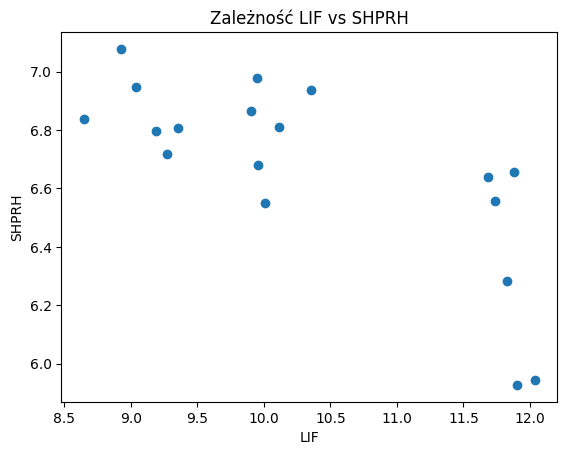

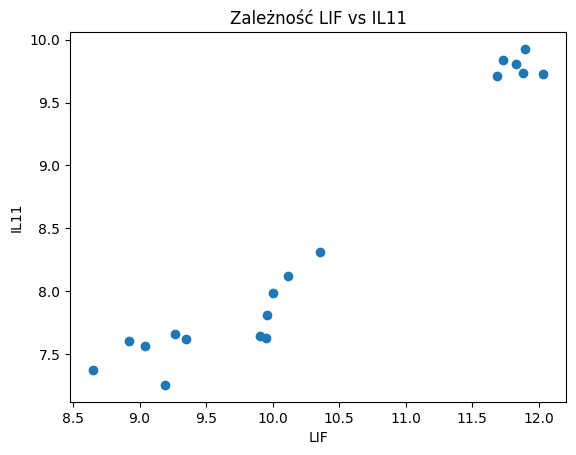

In [87]:
df = pd.read_csv('genes_cig.txt', sep = ",")
plt.scatter(df["LIF"], df["SHPRH"])
plt.ylabel("SHPRH")
plt.xlabel("LIF")
plt.title("Zależność LIF vs SHPRH")
plt.show()

plt.scatter(df["LIF"], df["IL11"])
plt.ylabel("IL11")
plt.xlabel("LIF")
plt.title("Zależność LIF vs IL11")
plt.show()

Zależność LIF od SHRPH jest raczej negatywnie skorelowana - im więcej LIF tym generalnie mniejszy poziom SHPRH, chociaż widać, że nie jest to zależność liniowa. Biologicznie oznacza to, że im mniejsza stabilność genomu i naprawa DNA tym większe stężenie cytokin LIF, zaangażowanych w szlak JAK/STAT3 co może wskazywać na odpowiedź immunologiczną na ten czynnik. Możliwe że obecność wirusa powoduje obniżenie poziomu SHRPH.

Natomiast odwrotnie jest w przypadku IL11 - im więcej IL11 tym więcej LIF, lecz także tutaj nie mamy do czynienia z zależnością liniową. Może to oznaczać że zachodzi coś w rodzaju dodatniego sprzężenia (?) - produkcja IL11 i tym samym aktywacja szlaku JAK/STAT3 indukuje wzmożoną produkcję LIF. Ciekawe jest że nie mamy próbek dla wartości pomiędzy 8.5 a 9.5 dla IL11, bo mogłoby to wskazywać na jakieś wartości progowe, ale ten przeskok równie dobrze może wynikać z małej ilości próbek. 

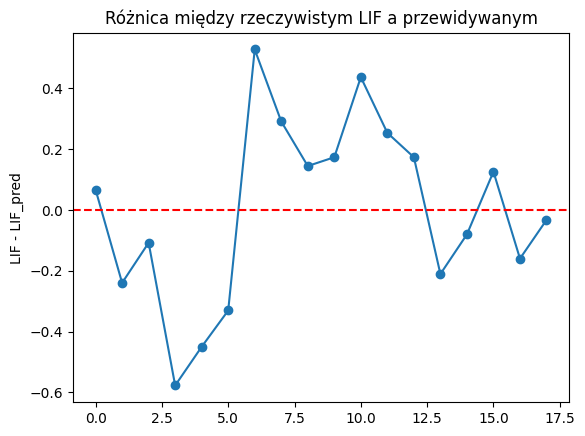

LIF = 0.0616 * (IL11^2) + -0.0002 * (SHPRH^4) + 6.2608
MSE: 0.083902


In [92]:
df = pd.read_csv('genes_cig.txt', sep = ",")
X = pd.DataFrame({
    'IL11_sq': df['IL11']**2,     # IL11 do 2 potęgi
    'SHPRH_4': df['SHPRH']**4     # SHPRH do 4 potęgi
})
y = df['LIF']

model = LinearRegression()
model.fit(X, y)

df['LIF_pred'] = model.predict(X)

df['Residual'] = df['LIF'] - df['LIF_pred']

plt.plot(df.index, df['Residual'], marker='o', linestyle='-')
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('LIF - LIF_pred')
plt.title('Różnica między rzeczywistym LIF a przewidywanym')
plt.show()

a, b = model.coef_  # współczynniki dla IL11 i SHPRH
c = model.intercept_  # wyraz wolny

print(f"LIF = {a:.4f} * (IL11^2) + {b:.4f} * (SHPRH^4) + {c:.4f}")

mse = mean_squared_error(y, df['LIF_pred'])
print(f"MSE: {mse:.6f}")

<h4> Zadanie2 (3pkt): Rozważ dane dotyczace lokalizacji komórkowej wybranych białek (peptydów).
    
- Pozostaw kategorie: MT (mitochondrialne), SP (sygnałowe), CH (chloroplastów), TH (lumen tylakoidów), czyli odrzuć rekordy Other
- Czy rozważany zbiór danych jest zbalansowany?
- Wybierz cechy do reprezentacji rozważanych sekwencji
- Narysuj histogramy/wykresy pudełkowe rozważanych cech względem kategorii
- Podziel dane na zbiór treningowy i testowy (ewentualnie wydziel jeszcze zbiór walidacyjny)
- Dokonaj standaryzacji danych
- Zbuduj model regresji logistycznej, które zmienne najbardziej istotne?

!!!Zbuduj wiele modeli, pokazując proces tworzenia bardziej użytecznych modeli!!! Co warto zrobić?
- class_weight='balanced' jako argument LR
- SMOTE (z imblearn) - dogenerować kolejne dane
- wybór innych cech
- rozważ nieliniowe transformacje
- rozważ regularyzację (zwłaszcza przy dużej liczbie cech)
- ... im więcej ciekawych pomysłów tym lepiej

In [94]:
# Wczytywanie pliku
df = pd.read_csv('swissprot_annotated_proteins.tab', sep='\t', header=None, names=['accession','loc','length'])
print(df.shape)
display(df.head())

(13005, 3)


,accession,loc,length
0,P10719,MT,46
1,Q38786,CH,55
2,P15289,SP,18
3,P25705,MT,43
4,P00829,MT,48


In [95]:
# Filtracja (odrzucenie Other) + sprawdzenie czy dane są zbilansowane
keep = ['MT','SP','CH','TH']
df = df[df['loc'].isin(keep)].copy()
print("Rozkład klas:\n", df['loc'].value_counts()) #dane NIE są zbilansowane

Rozkład klas:
 loc
SP    2697
MT     499
CH     227
TH      45
Name: count, dtype: int64


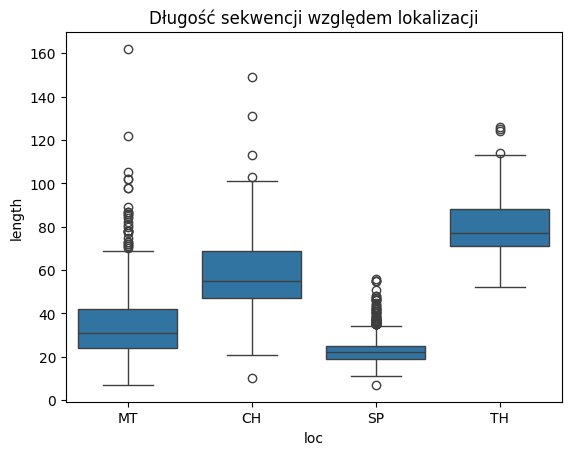

In [96]:
# Długość sekwencji vs przynależność do klasy/lokalizacja sekwencji
sns.boxplot(x='loc', y='length', data=df)
plt.title('Długość sekwencji względem lokalizacji')
plt.show()

In [100]:
# Prosty model klasyfikujący na podstawie jednej cechy - długości
X = df[['length']].values
y = df['loc'].values

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, stratify=y_enc, test_size=0.25, random_state=42)

scaler = StandardScaler().fit(Xtrain) #standaryzacja
Xtrain_s = scaler.transform(Xtrain)
Xtest_s = scaler.transform(Xtest)

model = LogisticRegression(multi_class='ovr', class_weight='balanced', penalty='l2', C=0.1)

#wybrałam takie parametry bo dane nie są zbilansowane (dlatego class_weight=balanced), zachodzi klasyfikacja wieloklasowa - na podstawie jednej cechy
#determinujemy przynależność do jednej z paru klas - MT, CH, SP czy TH (dlatego parametr multi_class='ovr', ponieważ model wtedy trenuje osobną 
#regresję dla każdej klasy - czyli tutaj mamy 4 modele, każdy z nich daje prawdopodobieństwo przynależności do danej klasy), zastosowałam regularyzację
#l2, ponieważ mamy jedną cechę na podstawie której jest dokonywana klasyfikacja a parametr C ustawiłam na dość niską wartość, jak wcześniej w przykładzie.

model.fit(Xtrain_s, ytrain)

ypred = model.predict(Xtest_s)
print(classification_report(ytest, ypred, target_names=le.classes_))
print("Confusion matrix:\n", confusion_matrix(ytest, ypred))
print('Dokładnośc na zbiorze treningowym:', model.score(Xtrain_s, ytrain))
print('Dokładność na zbiorze testowym:', model.score(Xtest_s, ytest))

              precision    recall  f1-score   support

          CH       0.52      0.81      0.63        57
          MT       0.36      0.28      0.31       125
          SP       0.90      0.91      0.91       674
          TH       0.00      0.00      0.00        11

    accuracy                           0.80       867
   macro avg       0.44      0.50      0.46       867
weighted avg       0.79      0.80      0.79       867

Confusion matrix:
 [[ 46   8   3   0]
 [ 27  35  63   0]
 [  5  55 614   0]
 [ 11   0   0   0]]
Dokładnośc na zbiorze treningowym: 0.8100730488273741
Dokładność na zbiorze testowym: 0.8016147635524798


In [76]:
#model z zastosowaniem SMOTE - dotworzenie sobie danych, aby były zbilansowane
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

print("Przed SMOTE:", Counter(y_train))

scaler = StandardScaler() #standaryzacja
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_s, y_train)

print("Po SMOTE:", Counter(y_res))

model_smote = LogisticRegression(multi_class='ovr', penalty='l2', C=0.1) #zastosowanie tych samych parametrów ale teraz dane sa zbilansowane yay!
model_smote.fit(X_res, y_res)

y_pred = model_smote.predict(X_test_s)
print(classification_report(y_test, y_pred))
print('Dokładnośc na zbiorze treningowym:', model_smote.score(X_train_s, y_train))
print('Dokładność na zbiorze testowym:', model_smote.score(X_test_s, y_test))

Przed SMOTE: Counter({'SP': 2023, 'MT': 374, 'CH': 170, 'TH': 34})
Po SMOTE: Counter({'SP': 2023, 'MT': 2023, 'TH': 2023, 'CH': 2023})
              precision    recall  f1-score   support

          CH       0.66      0.44      0.53        57
          MT       0.36      0.58      0.44       125
          SP       0.94      0.82      0.88       674
          TH       0.28      0.82      0.42        11

    accuracy                           0.76       867
   macro avg       0.56      0.67      0.57       867
weighted avg       0.83      0.76      0.78       867

Dokładnośc na zbiorze treningowym: 0.7577854671280276
Dokładność na zbiorze testowym: 0.76239907727797


In [97]:
#dodawanie nowych cech 
plik_fasta = "targetp.fasta"

ids = []
sqs = []

for rekord in SeqIO.parse(plik_fasta, "fasta"):
    ids.append(str(rekord.id))
    sqs.append(str(rekord.seq))

seq_dict = dict(zip(ids, sqs))

df["molecular_weight"] = None
df["isoelectric_point"] = None
df["gravy"] = None

for acc, seq in seq_dict.items():
    try:
        cleaned_seq = ''.join([aa for aa in seq if aa in "ACDEFGHIKLMNPQRSTVWY"])
        analysed_seq = ProteinAnalysis(cleaned_seq)
        mw = analysed_seq.molecular_weight()
        pI = analysed_seq.isoelectric_point()
        gravy = analysed_seq.gravy()

        df.loc[df["accession"] == acc, ["molecular_weight", "isoelectric_point", "gravy"]] = [mw, pI, gravy]

    except Exception as e:
        print(f"Błąd przy analizie {acc}: {e}")

print(df)

      accession loc  length molecular_weight isoelectric_point     gravy
0        P10719  MT      46       56352.8574          5.184762  0.034026
1        Q38786  CH      55       65039.8049          6.034107 -0.441638
2        P15289  SP      18        53587.561          5.648909  0.011637
3        P25705  MT      43       59749.8993          9.157363 -0.066727
4        P00829  MT      48       56282.8306          5.149579  0.042235
...         ...  ..     ...              ...               ...       ...
11096    O43653  SP      20        11958.755          4.749262  0.329825
11097    P35496  SP      21       14815.9466          8.928307  0.050365
11098    P11155  CH      62       102673.313          5.741045 -0.150475
11099    P12301  CH      83       24853.1335          9.750408 -0.293534
11100    P82411  CH      47       12064.5635          9.827125 -0.251724

[3468 rows x 6 columns]


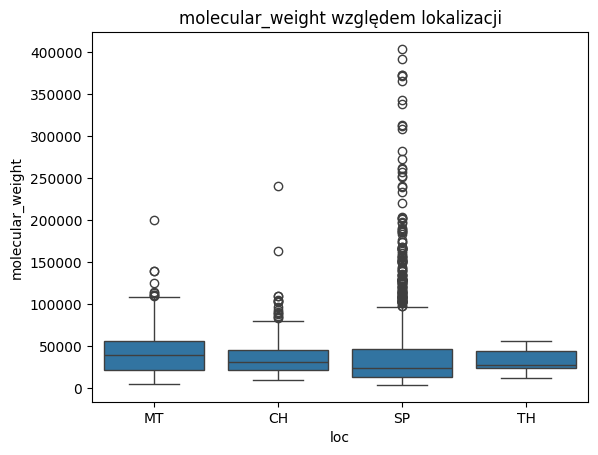

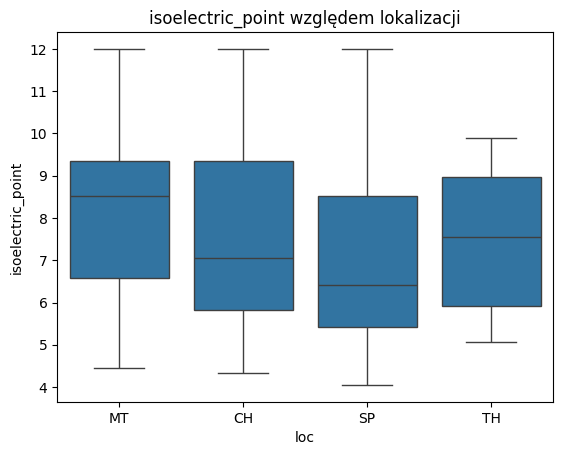

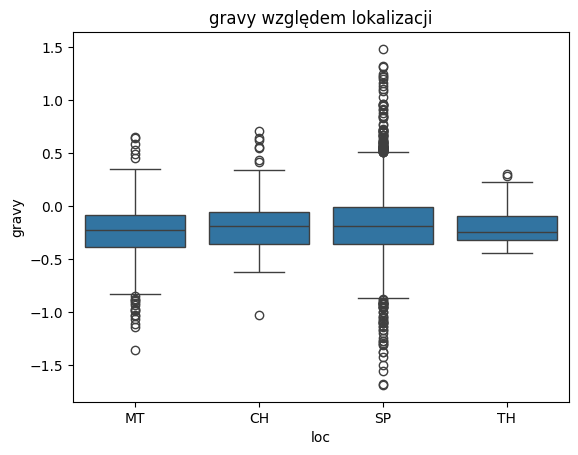

In [98]:
# Reszta cech vs przynależność do klasy/lokalizacja sekwencji
cechy = ["molecular_weight", "isoelectric_point", "gravy"]
for c in cechy:
    sns.boxplot(x='loc', y=c, data=df)
    plt.title(f'{c} względem lokalizacji')
    plt.show()

In [74]:
#trenowanie nowego modelu z nowymi cechami
X = df.drop(columns=['accession', 'loc'])
y = df['loc']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

scaler = StandardScaler().fit(X_train) #standaryzacja
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

model_duzy = LogisticRegression(multi_class='ovr', solver='liblinear', class_weight='balanced', penalty='l1', C=0.1)

#parametry zastosowane jak wcześniej - zmieniłam tylko regularyzację na l1, ze względu na większą ilość cech oraz dostosowałam do tego solvera, bo
#automatyczny solver lbfgs nie obsluguje tej regularyzacji (tylko l2)

model_duzy.fit(X_train_s, y_train)

y_pred = model_duzy.predict(X_test_s)

print(classification_report(y_test, y_pred))
print('Dokładnośc na zbiorze treningowym:', model_duzy.score(X_train_s, y_train))
print('Dokładność na zbiorze testowym:', model_duzy.score(X_test_s, y_test))

              precision    recall  f1-score   support

          CH       0.52      0.77      0.62        57
          MT       0.53      0.26      0.35       125
          SP       0.90      0.96      0.93       674
          TH       0.00      0.00      0.00        11

    accuracy                           0.83       867
   macro avg       0.49      0.50      0.47       867
weighted avg       0.81      0.83      0.81       867

Dokładnośc na zbiorze treningowym: 0.8354479046520569
Dokładność na zbiorze testowym: 0.8339100346020761


In [71]:
#duży model + SMOTE
X = df.drop(columns=['accession', 'loc'])
y = df['loc']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

scaler = StandardScaler() #standaryzacja
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_s, y_train)

model_duzy_SMOTE = LogisticRegression(multi_class='ovr', solver='liblinear', penalty='l1', C=0.1)
model_duzy_SMOTE.fit(X_res, y_res)

y_pred = model_duzy_SMOTE.predict(X_test_s)

print(classification_report(y_test, y_pred))
print('Dokładnośc na zbiorze treningowym:', model_duzy_SMOTE.score(X_train_s, y_train))
print('Dokładność na zbiorze testowym:', model_duzy_SMOTE.score(X_test_s, y_test))

              precision    recall  f1-score   support

          CH       0.65      0.42      0.51        57
          MT       0.36      0.58      0.45       125
          SP       0.94      0.83      0.88       674
          TH       0.27      0.82      0.41        11

    accuracy                           0.77       867
   macro avg       0.56      0.66      0.56       867
weighted avg       0.83      0.77      0.79       867

Dokładnośc na zbiorze treningowym: 0.7585544021530181
Dokładność na zbiorze testowym: 0.7658592848904268


Najlepszą dokładność miał model "duży" - czyli z dodatkowymi cechami ale, co ciekawe po dodaniu SMOTE, w celu zbilansowania danych, dokładność przewidywania dość drastycznie spadła - niżej nawet niż przy najprostszym modelu, który brał pod uwagę tylko jedną cechę - długość sekwencji i nie miał zbilansowanych danych. 